In [2]:
# import os
# from glob import glob
# import cv2
# import numpy as np
# from sklearn.cluster import KMeans
# import matplotlib.pyplot as plt

# # Parameters
# COLOR_SPACE = 'HSV'
# HIST_BINS = (8, 8, 8)
# MATCH_THRESHOLD = 0.6
# MIN_REGION_AREA = 1200

# # === Step 1: Extract histogram ===
# def extract_color_histogram(img, mask=None, bins=HIST_BINS):
#     img_cs = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
#     hist = cv2.calcHist([img_cs], [0, 1, 2], mask, bins, [0, 256, 0, 256, 0, 256])
#     hist = cv2.normalize(hist, hist).flatten()
#     return hist

# # === Step 2: Build reference model ===
# def build_reference_model(reference_folder):
#     model_db = {}
#     ref_sizes = []

#     for path in glob(os.path.join(reference_folder, "*.jpg")):
#         name = os.path.splitext(os.path.basename(path))[0]
#         img = cv2.imread(path)
#         hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
#         mask = cv2.inRange(hsv, (0, 30, 30), (180, 255, 255))
#         hist = extract_color_histogram(img, mask)
#         model_db[name] = hist

#         contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         if contours:
#             x, y, w, h = cv2.boundingRect(max(contours, key=cv2.contourArea))
#             ref_sizes.append((w, h))

#     avg_w = sum(w for w, h in ref_sizes) / len(ref_sizes)
#     avg_h = sum(h for w, h in ref_sizes) / len(ref_sizes)
#     return model_db, (avg_w, avg_h)

# # === Step 3: Clustering & region mask generation ===
# def get_cluster_mask(img, k_clusters=4):
#     img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
#     pixel_values = img_lab.reshape((-1, 3)).astype(np.float32)
#     kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init='auto')
#     labels = kmeans.fit_predict(pixel_values)
#     segmented_img = labels.reshape(img.shape[:2])
#     cluster_centers = kmeans.cluster_centers_
#     # Visual breakpoint___________________________________________________________________-
#     scale = 0.2  # Show at 20% size (adjust as needed)
#     display_img = cv2.resize(segmented_img, (0, 0), fx=scale, fy=scale)

#     cv2.imshow("Cluster Visualization", display_img)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

#     def is_chocolate_color(lab_color):
#         L, a, b = lab_color
#         return (20 < L < 80) and (10 < a < 30) and (10 < b < 30)

#     choco_clusters = [i for i, center in enumerate(cluster_centers) if is_chocolate_color(center)]
#     choco_mask = np.isin(segmented_img, choco_clusters).astype(np.uint8) * 255

#     # Cleanup
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
#     choco_mask = cv2.morphologyEx(choco_mask, cv2.MORPH_CLOSE, kernel)
#     choco_mask = cv2.medianBlur(choco_mask, 7)
#     return choco_mask

# # === Step 4: Watershed Splitting Helper ===
# def split_region_watershed(region_mask, ref_area=None, min_area=MIN_REGION_AREA):
#     region_mask = cv2.threshold(region_mask, 0, 255, cv2.THRESH_BINARY)[1]
#     dist = cv2.distanceTransform(region_mask, cv2.DIST_L2, 5)
#     dist = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)
#     _, peaks = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
#     peaks = (peaks * 255).astype("uint8")

#     contours, _ = cv2.findContours(peaks, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     markers = np.zeros(region_mask.shape, dtype=np.int32)
#     for i, cnt in enumerate(contours):
#         cv2.drawContours(markers, [cnt], -1, i + 1, -1)

#     region_color = cv2.cvtColor(region_mask, cv2.COLOR_GRAY2BGR)
#     cv2.watershed(region_color, markers)

#     boxes = []
#     for label in np.unique(markers):
#         if label <= 0:
#             continue
#         mask = np.uint8(markers == label)
#         cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         for c in cnts:
#             x, y, w, h = cv2.boundingRect(c)
#             area = cv2.contourArea(c)
#             if area < min_area:
#                 continue
#             if ref_area and not (0.4 * ref_area <= w * h <= 2.5 * ref_area):
#                 continue
#             boxes.append((x, y, w, h))
#     return boxes

# # === Step 5: From mask to bounding boxes ===
# def find_bounding_boxes(mask, ref_size=None):
#     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     boxes = []
#     ref_area = ref_size[0] * ref_size[1] if ref_size else None

#     for cnt in contours:
#         area = cv2.contourArea(cnt)
#         if area < MIN_REGION_AREA:
#             continue

#         x, y, w, h = cv2.boundingRect(cnt)
#         aspect_ratio = max(w / h, h / w)
#         if aspect_ratio > 4:
#             continue

#         candidate_area = w * h
#         use_splitting = ref_area and candidate_area > 3 * ref_area

#         if use_splitting:
#             region_mask = mask[y:y+h, x:x+w].copy()
#             sub_boxes = split_region_watershed(region_mask, ref_area=ref_area)
#             for sx, sy, sw, sh in sub_boxes:
#                 boxes.append((x + sx, y + sy, sw, sh))
#         else:
#             boxes.append((x, y, w, h))
#     return boxes

# # === Step 6: Histogram matching ===
# def match_chocolates(img, boxes, model_db, expansion=10):
#     results = []
#     h_img, w_img = img.shape[:2]
#     for (x, y, w, h) in boxes:
#         x1 = max(0, x - expansion)
#         y1 = max(0, y - expansion)
#         x2 = min(w_img, x + w + expansion)
#         y2 = min(h_img, y + h + expansion)
#         roi = img[y1:y2, x1:x2]
#         hist = extract_color_histogram(roi)

#         best_label = None
#         best_score = float('inf')
#         for label, ref_hist in model_db.items():
#             score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_BHATTACHARYYA)
#             if score < best_score:
#                 best_score = score
#                 best_label = label

#         if best_score < MATCH_THRESHOLD:
#             results.append((x, y, w, h, best_label, best_score))
#     return results

# # === Step 7: Draw detections ===
# def draw_detections(img, detections):
#     for (x, y, w, h, label, score) in detections:
#         cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
#         text = f"{label} ({score:.2f})"
#         cv2.putText(img, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 200, 255), 2)
#     return img

# # === Step 8: MAIN EXECUTION ===
# reference_folder = r'images\reference_images'
# test_folder = r'images\valid'

# model_db, ref_size = build_reference_model(reference_folder)

# for test_path in glob(os.path.join(test_folder, "*.jpg")):
#     print(f"\nProcessing {os.path.basename(test_path)}")
#     img = cv2.imread(test_path)

#     mask = get_cluster_mask(img)
#     boxes = find_bounding_boxes(mask, ref_size=ref_size)
#     detections = match_chocolates(img, boxes, model_db)

#     print(f"  Detected {len(detections)} chocolates.")

#     result = draw_detections(img.copy(), detections)
#     plt.figure(figsize=(10, 6))
#     plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
#     plt.title(f"Detections: {os.path.basename(test_path)}")
#     plt.axis('off')
#     plt.show()


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# # Convert to grayscale and threshold
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# _, img_th = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

# # Define morphological operations using OpenCV
# def apply_closing(img_th, disk_size):
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
#     return cv2.morphologyEx(img_th, cv2.MORPH_CLOSE, kernel)

# def apply_opening(img_th, disk_size):
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
#     return cv2.morphologyEx(img_th, cv2.MORPH_OPEN, kernel)

# def remove_holes(img_th, size):
#     inv = cv2.bitwise_not(img_th)
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(inv, connectivity=8)
#     cleaned = inv.copy()
#     for i in range(1, num_labels):
#         if stats[i, cv2.CC_STAT_AREA] < size:
#             cleaned[labels == i] = 0
#     return cv2.bitwise_not(cleaned)

# def remove_objects(img_th, size):
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(img_th, connectivity=8)
#     cleaned = np.zeros_like(img_th)
#     for i in range(1, num_labels):
#         if stats[i, cv2.CC_STAT_AREA] >= size:
#             cleaned[labels == i] = 255
#     return cleaned

# # Your combined morphology function
# def apply_morphology(img_th):
#     img_morph = np.zeros_like(img_th)
#     img_morph = remove_objects(
#                     remove_holes(
#                         apply_opening(
#                             apply_closing(img_th, 2), 3),
#                         100),
#                     100)
#     return img_morph




In [5]:
# def detect_edges(gray):
#     blurred = cv2.GaussianBlur(gray, (5, 5), 0)
#     edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
#     return edges


In [6]:
# def get_contours(edges):
#     contours, _ = cv2.findContours(edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     return contours

In [7]:
def draw_contours(image, contours, labels=None):
    boxed = image.copy()
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(boxed, (x, y), (x + w, y + h), (0, 255, 0), 3)
        if labels and i < len(labels):
            cv2.putText(boxed, labels[i], (x, y + 40), cv2.FONT_HERSHEY_SIMPLEX,
                        2.0, (0, 0, 255), 4, lineType=cv2.LINE_AA)
    return boxed



In [8]:
# def segment_objects(image, contours):
#     masks = []
#     for cnt in contours:
#         if cv2.contourArea(cnt) > 500:
#             mask = np.zeros(image.shape[:2], dtype=np.uint8)
#             cv2.drawContours(mask, [cnt], -1, 255, -1)
#             masked = cv2.bitwise_and(image, image, mask=mask)
#             masks.append(masked)
#     return masks


In [9]:
# def color_mask_hsv(image):
#     hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
#     # Chocolate-like color range (adjust as needed)
#     lower = np.array([5, 50, 20])
#     upper = np.array([30, 255, 255])
    
#     mask = cv2.inRange(hsv, lower, upper)
#     return mask


In [10]:
# def get_filtered_contours(mask, min_area=1000):
#     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     filtered = []
#     for c in contours:
#         area = cv2.contourArea(c)
#         if area < min_area:
#             continue
#         x, y, w, h = cv2.boundingRect(c)
#         aspect_ratio = w / float(h)
#         extent = area / (w * h)
#         if 0.3 < aspect_ratio < 3.5 and extent > 0.3:
#             filtered.append(c)
#     return filtered

In [11]:
# def bright_region_mask(image):
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     # Adaptive threshold to find brighter blobs (e.g., white chocolate)
#     return cv2.adaptiveThreshold(
#         gray, 255,
#         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#         cv2.THRESH_BINARY,
#         11,  # block size
#         -10  # subtractive constant (tune this)
#     )


In [12]:
# def morphology(img):
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     _, img_th = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)

#     # 2. Code 1: Morphology-based Mask
#     morph_mask = apply_morphology(img_th)

#     # shadow_mask = preprocess_shadow(img)
#     # morph_mask = apply_morphology(shadow_mask)

#     # 3. Code 2: Color/Edge/Adaptive Mask
#     edges = detect_edges(img)
#     color_mask = color_mask_hsv(img)
#     bright_mask = bright_region_mask(img)
#     combined_mask = cv2.bitwise_or(edges, color_mask)
#     combined_mask = cv2.bitwise_or(combined_mask, bright_mask)

#     # Morphological Cleaning (Code 2 style)
#     opened = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
#     closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)))

#     # 4. Combine Both Masks
#     final_mask = cv2.bitwise_or(morph_mask, closed)

#     # Optional clean-up
#     final_mask = remove_holes(final_mask, size=100)
#     final_mask = remove_objects(final_mask, size=1500)

#     # 5. Get Contours and Draw
#     final_contours = get_filtered_contours(final_mask, min_area=1500)
#     boxed_img = draw_contours(img, final_contours)
    
#     return final_contours


In [13]:
# # Fist try of implementing whole pipeline
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans
# import os
# from glob import glob

# # ---------- PARAMETERS ----------
# HIST_BINS = (8, 8, 8)
# K_CLUSTERS = 4
# MIN_REGION_AREA = 1000
# MATCH_THRESHOLD = 0.6

# # ---------- HISTOGRAM & MODEL ----------
# def extract_color_histogram(img, mask=None, bins=HIST_BINS):
#     hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
#     hist = cv2.calcHist([hsv], [0, 1, 2], mask, bins, [0, 256, 0, 256, 0, 256])
#     return cv2.normalize(hist, hist).flatten()

# def load_reference_models(ref_folder):
#     db = {}
#     for path in glob(os.path.join(ref_folder, "*.jpg")):
#         name = os.path.splitext(os.path.basename(path))[0]
#         img = cv2.imread(path)
#         if img is None:
#             continue
#         mask = cv2.inRange(cv2.cvtColor(img, cv2.COLOR_BGR2HSV), (0, 30, 30), (180, 255, 255))
#         db[name] = extract_color_histogram(img, mask)
#     return db

# # ---------- MORPHOLOGY OPERATIONS ----------
# def apply_closing(img_th, disk_size):
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
#     return cv2.morphologyEx(img_th, cv2.MORPH_CLOSE, kernel)

# def apply_opening(img_th, disk_size):
#     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (disk_size, disk_size))
#     return cv2.morphologyEx(img_th, cv2.MORPH_OPEN, kernel)

# def remove_holes(img_th, size):
#     inv = cv2.bitwise_not(img_th)
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(inv)
#     for i in range(1, num_labels):
#         if stats[i, cv2.CC_STAT_AREA] < size:
#             inv[labels == i] = 0
#     return cv2.bitwise_not(inv)

# def remove_objects(img_th, size):
#     num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(img_th)
#     output = np.zeros_like(img_th)
#     for i in range(1, num_labels):
#         if stats[i, cv2.CC_STAT_AREA] >= size:
#             output[labels == i] = 255
#     return output

# def clean_cluster_mask(mask):
#     mask = apply_closing(mask, 3)
#     mask = apply_opening(mask, 3)
#     mask = remove_holes(mask, 100)
#     mask = remove_objects(mask, MIN_REGION_AREA)
#     return mask

# # ---------- CLUSTERING ----------
# def kmeans_cluster_image(img, k=K_CLUSTERS):
#     lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)
#     Z = lab.reshape((-1, 3)).astype(np.float32)
#     kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Z)
#     labels = kmeans.labels_.reshape(img.shape[:2])
#     centers = kmeans.cluster_centers_
#     return labels, centers

# def label_to_color(labels, centers):
#     h, w = labels.shape
#     segmented = np.zeros((h, w, 3), dtype=np.uint8)
#     for i, center in enumerate(centers):
#         mask = (labels == i)
#         color = cv2.cvtColor(np.uint8([[center]]), cv2.COLOR_Lab2BGR)[0, 0]
#         segmented[mask] = color
#     return segmented

# # ---------- MAIN PIPELINE ----------
# def pipeline(img_path, ref_folder):
#     img = cv2.imread(img_path)
#     if img is None:
#         raise FileNotFoundError("Image not found")

#     ref_db = load_reference_models(ref_folder)

#     # 1. KMeans clustering
#     labels, centers = kmeans_cluster_image(img)
#     clustered_img = label_to_color(labels, centers)

#     # DEBUG 1: Show clustered image
#     cv2.imshow("Clustered Image", clustered_img)
#     cv2.waitKey(0)

#     # 2. Process each cluster
#     results_img = img.copy()
#     for cluster_id in range(K_CLUSTERS):
#         cluster_mask = (labels == cluster_id).astype(np.uint8) * 255
#         cleaned_mask = clean_cluster_mask(cluster_mask)

#         # DEBUG 2: Show mask per cluster
#         cv2.imshow(f"Cluster {cluster_id} mask (cleaned)", cleaned_mask)
#         cv2.waitKey(0)

#         # 3. Find bounding boxes
#         contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         for cnt in contours:
#             if cv2.contourArea(cnt) < MIN_REGION_AREA:
#                 continue
#             x, y, w, h = cv2.boundingRect(cnt)
#             roi = img[y:y+h, x:x+w]
#             hist = extract_color_histogram(roi)

#             # 4. Match with reference
#             best_label, best_score = None, -1
#             for name, ref_hist in ref_db.items():
#                 score = cv2.compareHist(hist, ref_hist, cv2.HISTCMP_CORREL)
#                 if score > best_score:
#                     best_score = score
#                     best_label = name

#             if best_score >= MATCH_THRESHOLD:
#                 cv2.rectangle(results_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
#                 cv2.putText(results_img, f"{best_label} ({best_score:.2f})", (x, y-10),
#                             cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

#     # DEBUG 3: Final result
#     cv2.imshow("Final Result", results_img)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

# # ---------- RUN ----------
# # Replace with your image and reference folder
# pipeline(
#     img_path=r'images/train/L1000826_JPG.rf.a372fc6f59a8e80a3da270e5186e58a2.jpg',
#     ref_folder='images/reference'
# )


In [14]:
import os
import cv2
import numpy as np
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
from glob import glob

# --------- Step 1: K-means Color Clustering ---------
def kmeans_clustering(image, k=4):
    Z = image.reshape((-1, 3))
    Z = np.float32(Z)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(Z)
    labels = kmeans.labels_.reshape(image.shape[:2])
    clustered_img = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)
    return clustered_img, labels

def extract_class_masks(labels, num_classes=4):
    masks = []
    for i in range(num_classes):
        mask = np.uint8(labels == i) * 255
        masks.append(mask)
    return masks

def clean_mask(mask):
    # Larger kernels to suppress small dots and merge nearby blobs
    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)
    
    # Optional: strengthen structure further
    dilated = cv2.dilate(closed, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)
    return dilated


def get_contours_from_mask(mask, min_area=1500, size_range=(450, 700)): #Change here 450 to 700
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        if (min_area < cv2.contourArea(c) and
            size_range[0] <= w <= size_range[1] and
            size_range[0] <= h <= size_range[1]):
            filtered.append(c)
    return filtered


# --------- Step 3: Histogram Extraction ---------
def extract_histogram(img, contour):
    x, y, w, h = cv2.boundingRect(contour)
    roi = img[y:y+h, x:x+w]
    hist = cv2.calcHist([roi], [0, 1, 2], None, [8,8,8], [0,256,0,256,0,256])
    cv2.normalize(hist, hist)
    return hist.flatten()

def match_histogram(hist, reference_histograms):
    return max(reference_histograms.items(),
               key=lambda item: cv2.compareHist(hist, item[1], cv2.HISTCMP_CORREL))[0]


# --------- Step 4: Reference Histogram Creation ---------
def load_reference_histograms(ref_folder):
    histograms = {}
    for path in glob(os.path.join(ref_folder, '*.jpg')):
        img = cv2.imread(path)
        clustered_img, labels = kmeans_clustering(img, k=4)
        masks = extract_class_masks(labels)
        for i, mask in enumerate(masks):
            cleaned = clean_mask(mask)
            contours = get_contours_from_mask(cleaned)
            if contours:
                hist = extract_histogram(img, contours[0])
                filename = os.path.basename(path)
                class_name = filename.split('_JPG')[0]
                histograms[class_name] = hist
                break
    return histograms


# --------- Step 5: Histogram Comparison ---------
def match_histogram(hist, reference_histograms):
    scores = {cls: cv2.compareHist(hist, ref, cv2.HISTCMP_CORREL) for cls, ref in reference_histograms.items()}
    return max(scores, key=scores.get)

# --------- Step 6: Run Full Pipeline on Image ---------
def process_image_kmeans_only(img_path, reference_histograms):
    img = cv2.imread(img_path)
    clustered_img, labels = kmeans_clustering(img, k=4)
    class_masks = extract_class_masks(labels)

    all_contours = []
    all_labels = []

    for mask in class_masks:
        cleaned = clean_mask(mask)
        contours = get_contours_from_mask(cleaned)
        for cnt in contours:
            hist = extract_histogram(img, cnt)
            best_label = match_histogram(hist, reference_histograms)
            all_contours.append(cnt)
            all_labels.append(best_label)

    display_results(img, clustered_img, all_contours, all_labels)


# --------- Visualization ---------
def display_results(orig, clustered, contours, labels):
    clustered_boxes = draw_contours(clustered, contours)
    original_boxes = draw_contours(orig.copy(), contours)
    labeled_img = draw_contours(orig.copy(), contours, labels)

    fig, axs = plt.subplots(1, 3, figsize=(20, 8))  # Slightly larger figure
    axs[0].imshow(cv2.cvtColor(clustered_boxes, cv2.COLOR_BGR2RGB))
    axs[0].set_title('K-means with BBoxes', fontsize=24)
    axs[1].imshow(cv2.cvtColor(original_boxes, cv2.COLOR_BGR2RGB))
    axs[1].set_title('Original with BBoxes', fontsize=24)
    axs[2].imshow(cv2.cvtColor(labeled_img, cv2.COLOR_BGR2RGB))
    axs[2].set_title('Final Classification', fontsize=24)

    for ax in axs:
        ax.axis('off')

    plt.tight_layout()
    plt.show()



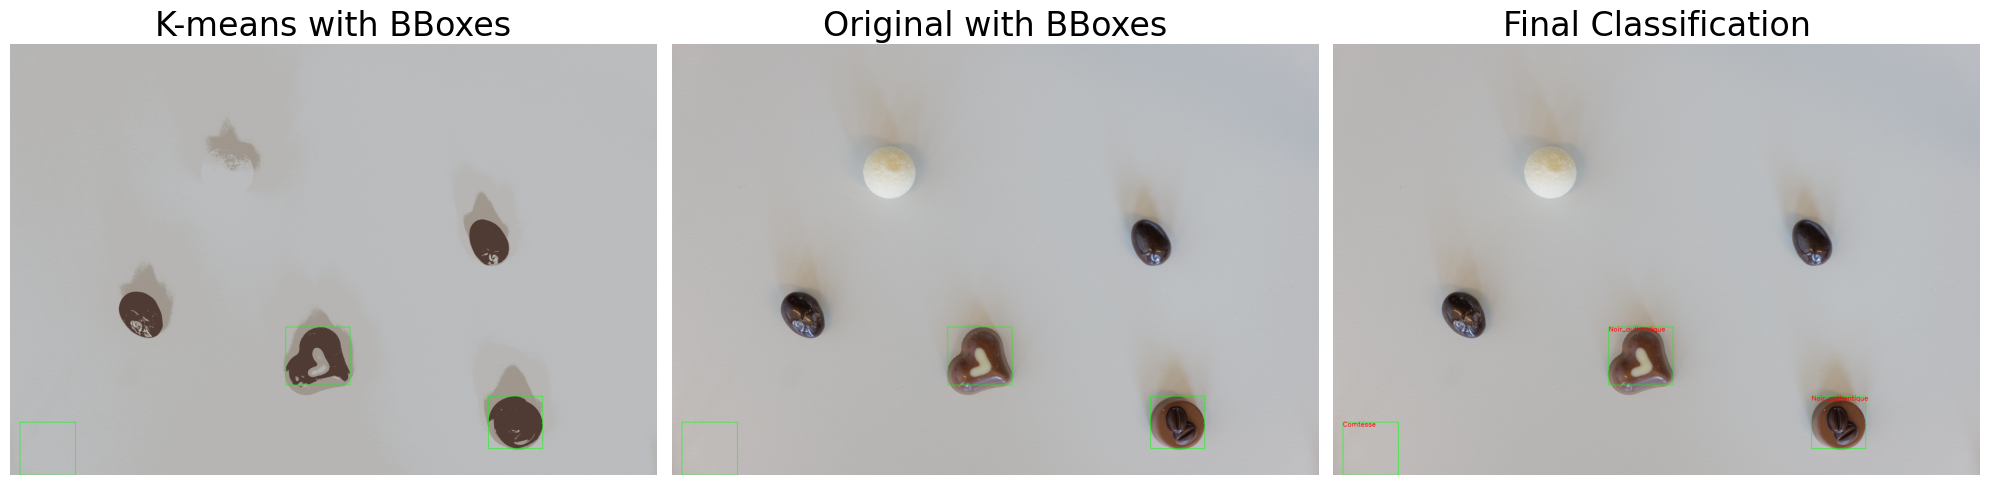

In [25]:
ref_histograms = load_reference_histograms(r'images\reference_images')
process_image_kmeans_only(r'images\test\L1000757.JPG', ref_histograms)

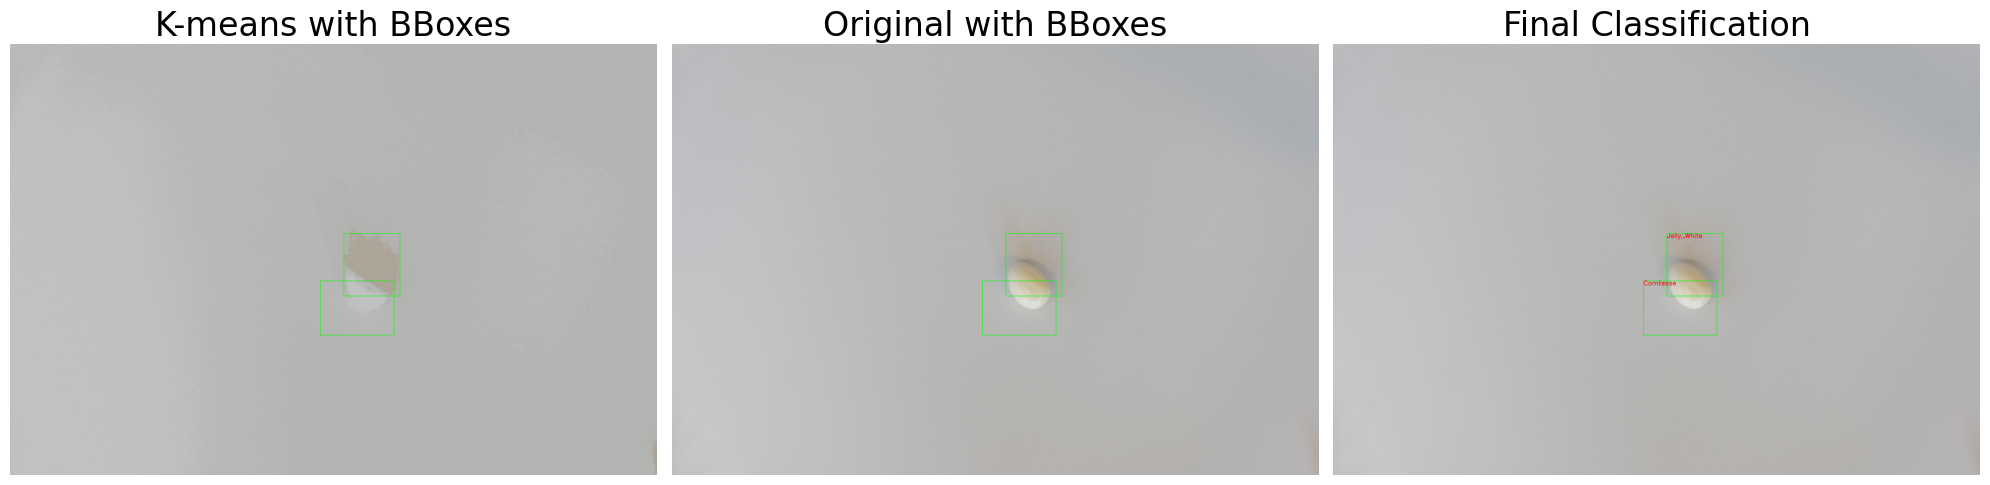

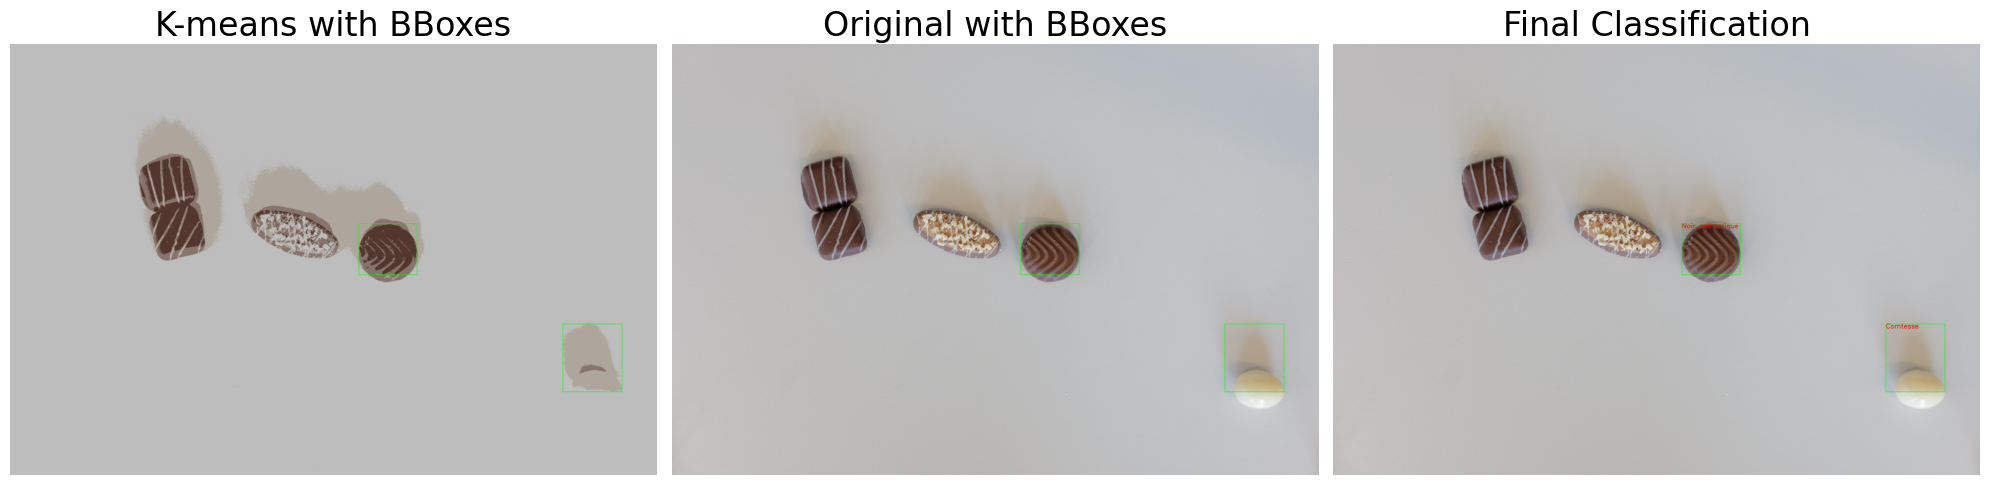

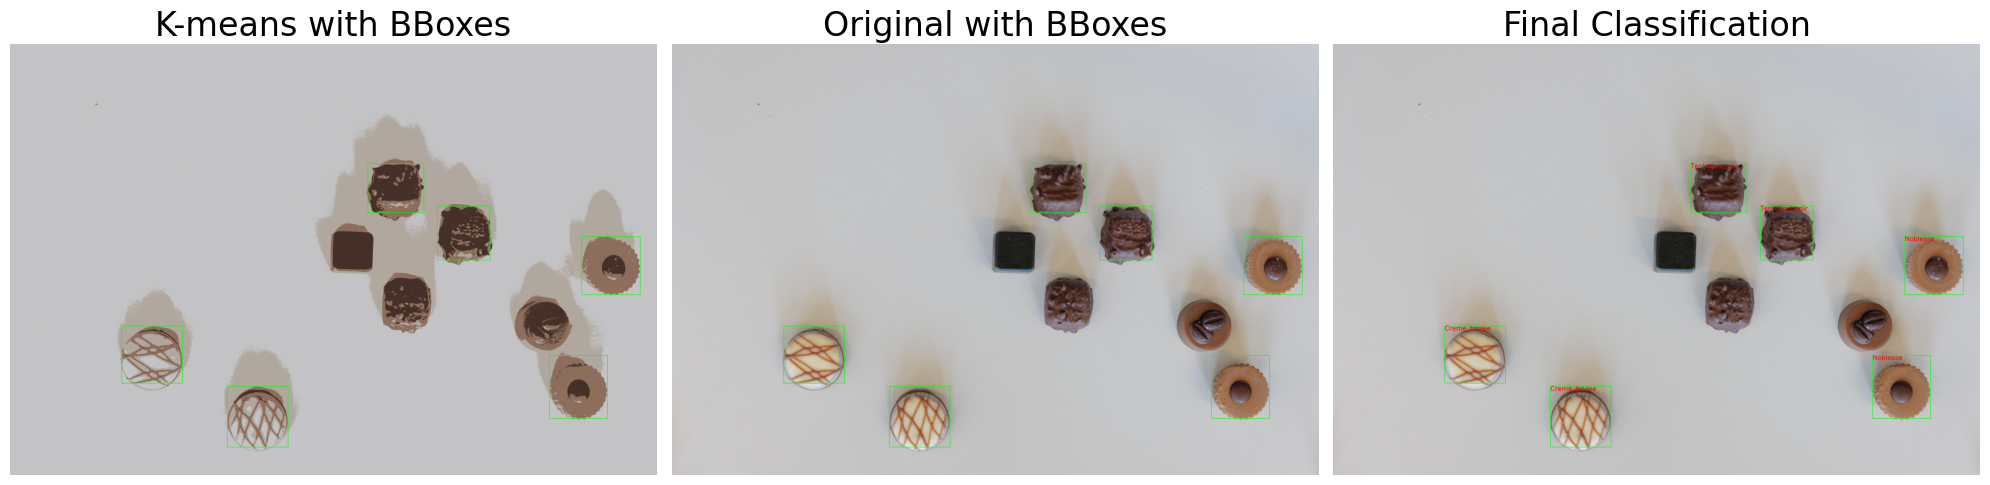

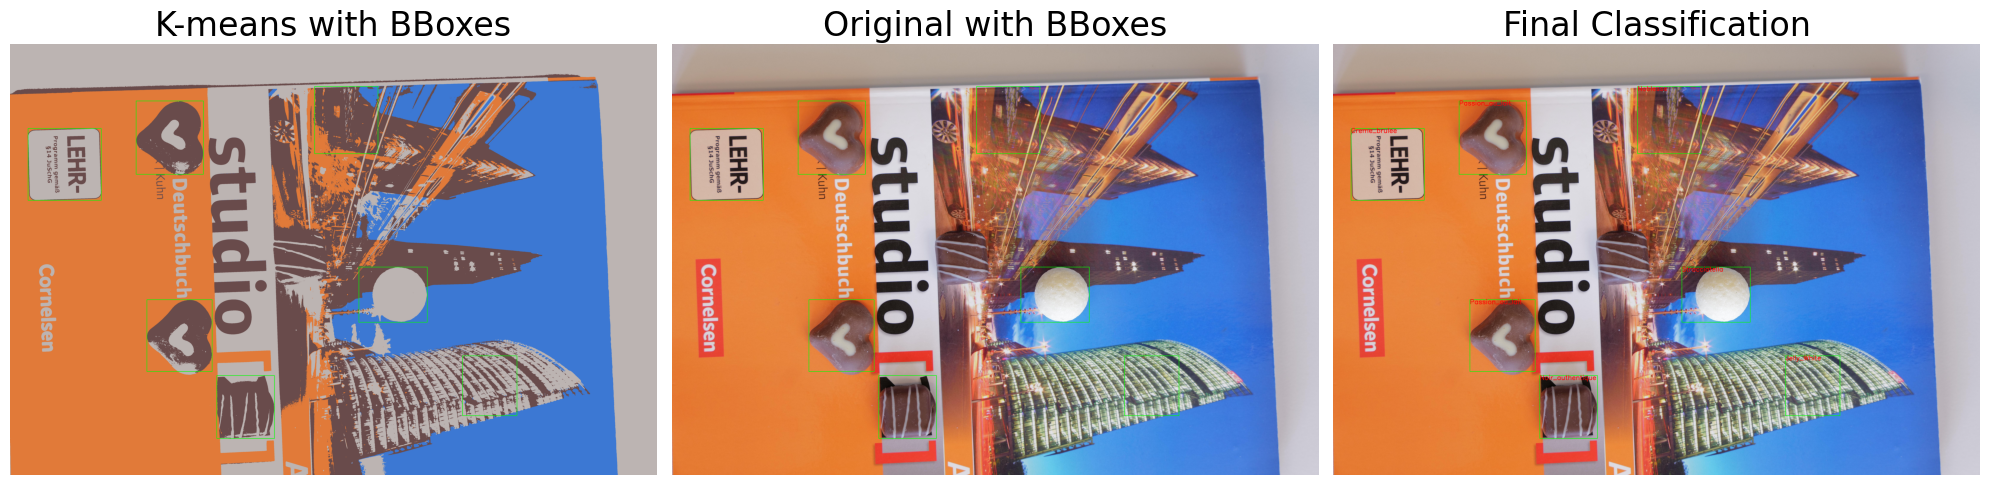

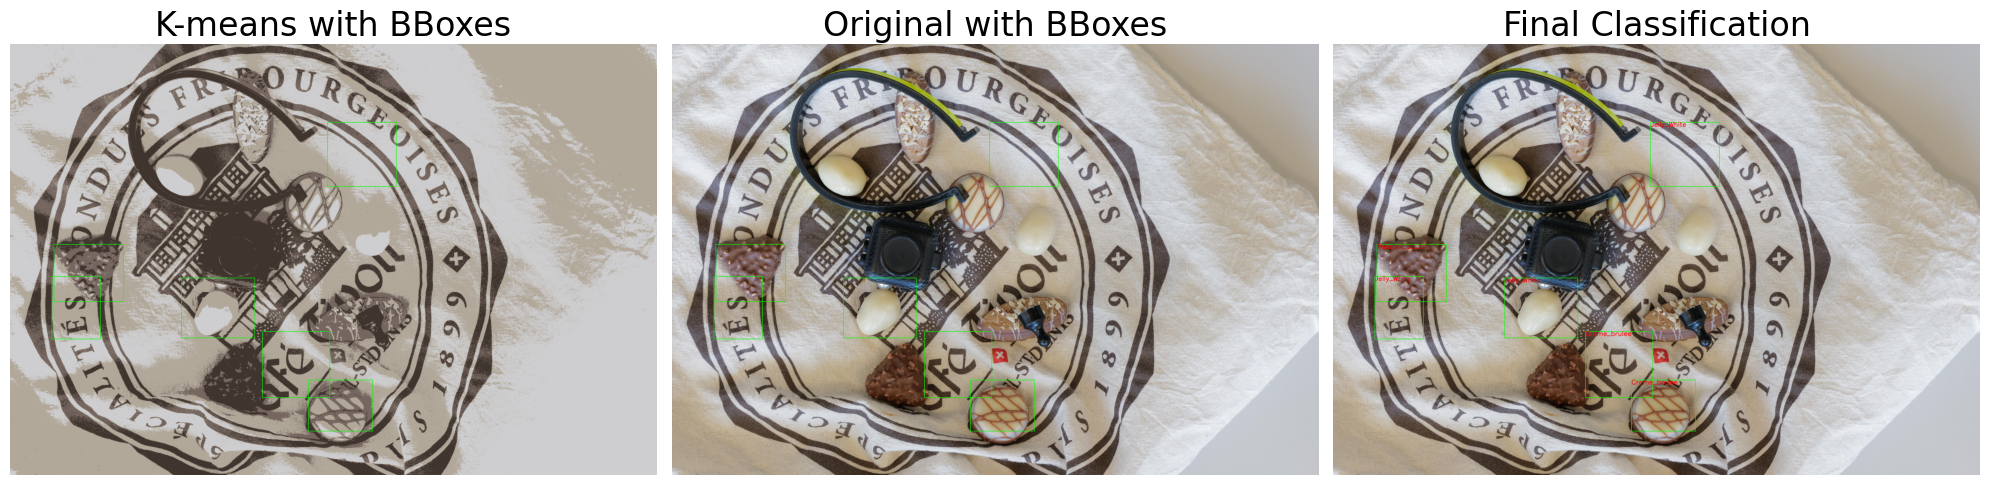

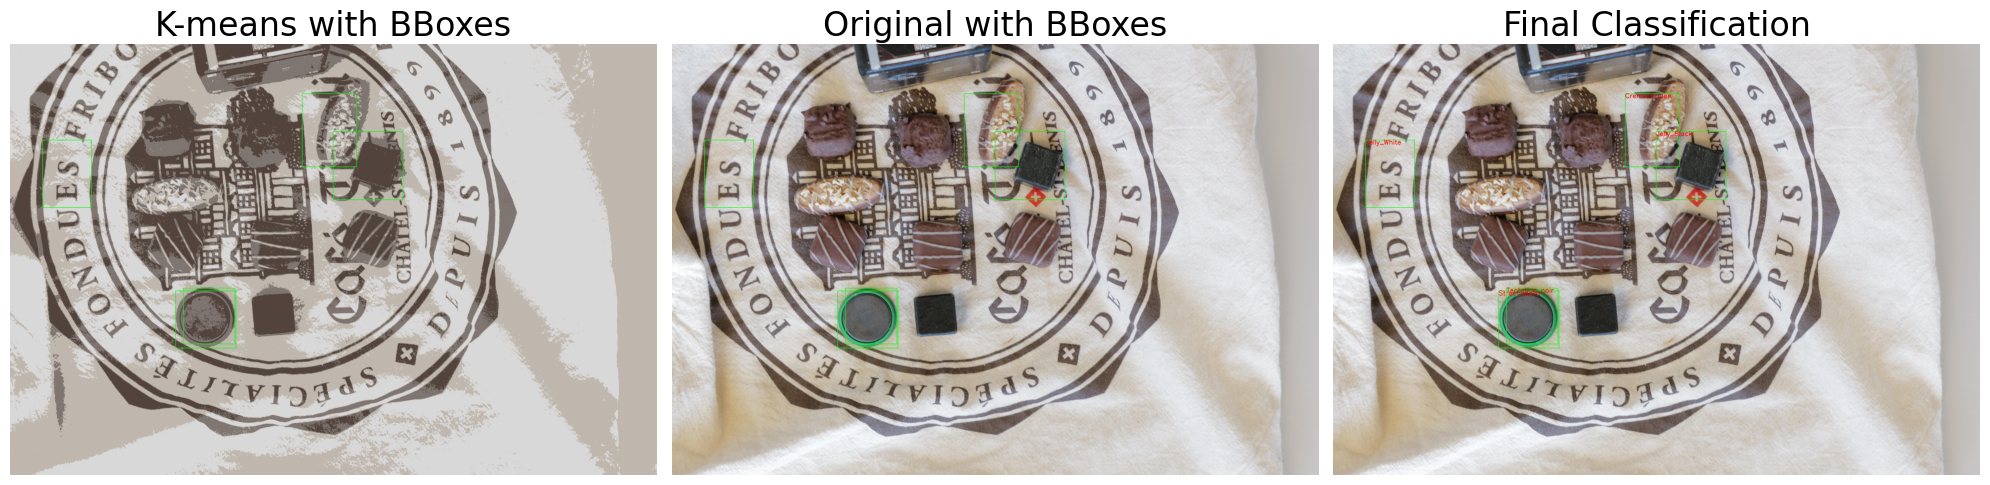

In [27]:
ref_histograms = load_reference_histograms(r'images\reference_images')
test_folder = r'images\valid_small'
for img_path in glob(os.path.join(test_folder, "*.jpg")):
    process_image_kmeans_only(img_path, ref_histograms)




In [18]:
# Expected labels (MUST match what your `load_reference_histograms` returns!)
EXPECTED_LABELS = [
    "Jelly_White", "Jelly_Milk", "Jelly_Black", "Amandina", "Creme_brulee",
    "Triangolo", "Tentation_noir", "Comtesse", "Noblesse", "Noir_authentique",
    "Passion_au_lait", "Arabia", "Stracciatella"
]

def process_image_for_counts(img_path, reference_histograms):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        return None
    
    clustered_img, labels = kmeans_clustering(img, k=4)
    class_masks = extract_class_masks(labels)

    label_counts = {label: 0 for label in EXPECTED_LABELS}

    for mask in class_masks:
        cleaned = clean_mask(mask)
        contours = get_contours_from_mask(cleaned)
        for cnt in contours:
            hist = extract_histogram(img, cnt)
            best_label = match_histogram(hist, reference_histograms)
            if best_label in label_counts:
                label_counts[best_label] += 1
            else:
                print(f"Unrecognized label: {best_label}")

    return label_counts


In [23]:
import csv

def generate_csv(test_folder, reference_histograms, output_csv):
    with open(output_csv, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['id'] + EXPECTED_LABELS)  # Header

        for img_path in glob(os.path.join(test_folder, '*.jpg')):
            filename = os.path.basename(img_path)

            # New ID extraction logic
            if filename.lower().startswith('l') and filename.lower().endswith('.jpg'):
                img_id = filename[1:filename.lower().rindex('.')]  # e.g., L1000757.JPG → 1000757
            else:
                print(f"Unexpected filename format: {filename}")
                continue

            counts = process_image_for_counts(img_path, reference_histograms)
            if counts is not None:
                row = [img_id] + [counts[label] for label in EXPECTED_LABELS]
                writer.writerow(row)
                print(f"Processed: {img_id}")



In [26]:
ref_histograms = load_reference_histograms(r'images\reference_images')
generate_csv(
    test_folder=r'images\test2',
    reference_histograms=ref_histograms,
    output_csv='chocolate_counts2.csv'
)


Processed: 1000757
Processed: 1000758
Processed: 1000759
Processed: 1000760
Processed: 1000761
Processed: 1000762
